# Gaussian Processes Summer School

## Part 2: Spectral Mixtures

<a href="https://www.uc3m.es/"><img src="./uc3m.png" alt="Universidad Carlos III de Madrid" width="520"></a>

**Author:** [Pablo M. Olmos](https://olmos-pm.github.io/)

**Email:** [pamartin@ing.uc3m.es](mailto:pamartin@ing.uc3m.es)

---

### Categorical mixture of stationary Gaussian processes

This notebook uses `generate_gp_mixture.py` to sample curves from three locally periodic GP components, with periods $T \in \{1, 0.5, 0.25\}$ and angular frequencies $\omega = 2\pi/T$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from generate_gp_mixture import generate_gp_mixture, locally_periodic_kernel

plt.style.use("seaborn-v0_8-whitegrid")

## Generate the dataset

### The locally periodic kernel

For simplicity, let's focus in the 1 dimensional case. The **stationary locally periodic kernel** can be written as follows

$$k(x,x')=k(\tau)=\sigma_f^2\exp\!\left(-\frac{\tau^2}{2\ell^2}\right)\cos(\omega_m\tau),\qquad \tau=x-x',$$

where $\omega_m=2\pi/T_m$. The RBF factor is a smooth envelope and the cosine creates oscillation at the component frequency.

#### Intuition

The kernel is **stationary** because it depends only on the lag $\tau=x-x'$, not on the absolute locations. It is useful to read it as the product of two effects:

- $\cos(\omega_m\tau)$ specifies the preferred oscillation and repeats every $T_m=2\pi/\omega_m$.
- $\exp[-\tau^2/(2\ell^2)]$ is a memory envelope that gradually suppresses this periodic relationship as two locations move apart.

At zero lag, $k(0)=\sigma_f^2$, so $\sigma_f^2$ is the marginal signal variance. At half a period $\tau = T_m/2$, the cosine is $-1$, so a high value tends to correspond to a low value half a cycle later:

$$k(T_m/2)=-\sigma_f^2\exp\!\left(-\frac{T_m^2}{8\ell^2}\right).$$

After one complete period the covariance is positive again, but its magnitude has decayed:

$$k(T_m)=\sigma_f^2\exp\!\left(-\frac{T_m^2}{2\ell^2}\right).$$

Thus the model prefers locally sinusoidal behavior without requiring the same pattern to repeat forever. When $|\tau|\gg\ell$, the envelope is nearly zero and even points at the same nominal phase become almost unrelated. This is the main difference from a strictly periodic kernel, whose correlations repeat indefinitely.

The dimensionless ratio $\ell/T_m$ gives a rough count of how many cycles fit inside one correlation length. For this dataset:

| period $T_m$ | $\ell/T_m$ | interpretation |
|---:|---:|:---|
| $1.0$ | $0.6$ | less than one cycle per correlation length |
| $0.5$ | $1.2$ | about one coherent cycle |
| $0.25$ | $2.4$ | several rapid cycles before decorrelation |

Increasing $\ell$ produces longer, more regular wave trains. Decreasing it produces shorter oscillatory bursts with faster phase and amplitude drift. The latent GP paths remain smooth because both factors in the kernel are infinitely differentiable; the small independent observation noise is what adds visible point-to-point jitter.

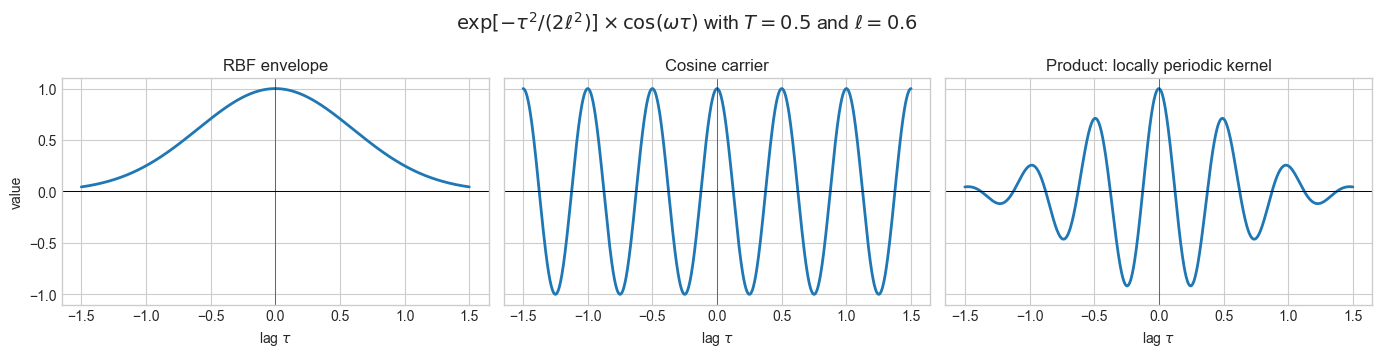

In [2]:
# One representative component: T=0.5 and ell=0.6
demo_tau = np.linspace(-1.5, 1.5, 1000)
demo_period = 0.5
demo_lengthscale = 0.6
demo_omega = 2.0 * np.pi / demo_period

# Compute the RBF envelope and cosine carrier separately, then multiply them to get the locally periodic kernel
rbf_envelope = np.exp(-demo_tau**2 / (2.0 * demo_lengthscale**2))
cosine_carrier = np.cos(demo_omega * demo_tau)
locally_periodic = rbf_envelope * cosine_carrier

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharex=True, sharey=True)
panels = [
    (rbf_envelope, r"RBF envelope"),
    (cosine_carrier, r"Cosine carrier"),
    (locally_periodic, r"Product: locally periodic kernel"),
]
for ax, (values, title) in zip(axes, panels):
    ax.plot(demo_tau, values, color="tab:blue", linewidth=2)
    ax.axhline(0.0, color="black", linewidth=0.7)
    ax.axvline(0.0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel(r"lag $\tau$")
axes[0].set_ylabel("value")
fig.suptitle(
    r"$\exp[-\tau^2/(2\ell^2)] \times \cos(\omega\tau)$"
    rf" with $T={demo_period}$ and $\ell={demo_lengthscale}$",
    fontsize=14,
)
fig.tight_layout()
plt.show()

#### Why this gives two Gaussian spectral bands: Bochner's theorem

Recall our expression for stationary kernels in the frequency domain that can be represented by an absolutely continous measure and admit a spectral pdf $p(\omega)$ representation:


<div style="display:block; box-sizing:border-box; width:100%; max-width:100%; overflow-x:auto; white-space:normal; background-color:#e8f1fd; border:2px solid #1565c0; border-radius:8px; padding:14px 18px; margin:14px 0; color:#0d47a1;">

$$k(\tau)=\int\cos(\omega^\top\tau)p(\omega)d\omega=\mathbb E_{\omega\sim p}[\cos(\omega^\top\tau)].$$

</div>

where $p(\omega)$ is a spectral probability density over $\omega\in\mathbb R^d$. In the 1D case,  for the locally periodic kernel $k(\tau)=\sigma_f^2\exp\!\left(-\frac{\tau^2}{2\ell^2}\right)\cos(\omega_m\tau)$, we can write using Eurler's formula

$$\cos(\omega_m\tau)=\tfrac12e^{i\omega_m\tau}+\tfrac12e^{-i\omega_m\tau}.$$

And similarly to how we prove that the RBF kernel is described by the spectral density $\omega \sim \mathcal{N}(0, \ell^{-2})$, it can be shown that the normalized spectral density for the locally periodic kernel is

<div style="display:block; box-sizing:border-box; width:100%; max-width:100%; overflow-x:auto; white-space:normal; background-color:#e8f5e9; border:2px solid #2e7d32; border-radius:8px; padding:14px 18px; margin:14px 0; color:#1b5e20;">

$$p(\omega)=\tfrac12\mathcal N(\omega;\omega_m,\ell^{-2})+\tfrac12\mathcal N(\omega;-\omega_m,\ell^{-2}).$$

</div>

The two equal weights enforce the symmetry required for a real covariance. The centers $\pm\omega_m$ determine the oscillation frequency, while the spectral variance $\ell^{-2}$ determines each band's width: a larger $\ell$ gives narrower, more concentrated frequency bands and longer-lived oscillations; a smaller $\ell$ gives wider bands and faster loss of periodic coherence.


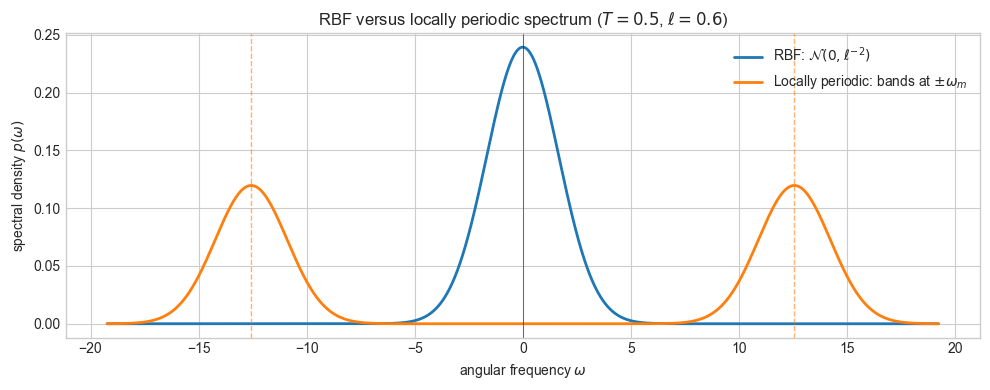

In [3]:
# Compare the normalized 1D spectral densities for the same ell and T used above.
spectral_std = 1.0 / demo_lengthscale
spectral_omega = np.linspace(
    -demo_omega - 4.0 * spectral_std,
    demo_omega + 4.0 * spectral_std,
    1600,
)

def normal_density(values, mean, std):
    return np.exp(-0.5 * ((values - mean) / std) ** 2) / (
        np.sqrt(2.0 * np.pi) * std
    )


rbf_spectrum = normal_density(spectral_omega, mean=0.0, std=spectral_std)
locally_periodic_spectrum = 0.5 * (
    normal_density(spectral_omega, mean=demo_omega, std=spectral_std)
    + normal_density(spectral_omega, mean=-demo_omega, std=spectral_std)
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(spectral_omega, rbf_spectrum, linewidth=2, label=r"RBF: $\mathcal{N}(0,\ell^{-2})$")
ax.plot(
    spectral_omega,
    locally_periodic_spectrum,
    linewidth=2,
    label=r"Locally periodic: bands at $\pm\omega_m$",
)
ax.axvline(0.0, color="black", linewidth=0.7, alpha=0.5)
ax.axvline(demo_omega, color="C1", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(-demo_omega, color="C1", linestyle="--", linewidth=1, alpha=0.6)
ax.set(
    title=rf"RBF versus locally periodic spectrum ($T={demo_period}$, $\ell={demo_lengthscale}$)",
    xlabel=r"angular frequency $\omega$",
    ylabel=r"spectral density $p(\omega)$",
)
ax.legend()
fig.tight_layout()
plt.show()


Note that, now that we know the spectral density $p(\omega)$ of the locally periodic kernel, using $D$ samples from such a density we can obtain an unbised MC estimate of the kernel matrix in a similar form

$$k(x-x')\approx z(x)^\top z(x')$$

where 

$$z(x)=\sqrt{\frac1D}[\cos(\omega_1^\top x),\sin(\omega_1^\top x),\ldots,\cos(\omega_D^\top x),\sin(\omega_D^\top x)]^\top.$$




## Our dataset: a mixture of GP models with oscillating kernels at different frequencies

We now combine three locally periodic GP components into a mixture. Let $x_1,\ldots,x_N$ be the common input grid and let $i=1,\ldots,n$ index independently generated signals. Each complete signal first chooses one latent component:

$$z_i\sim\operatorname{Categorical}(\pi_1,\pi_2,\pi_3).$$

Conditional on $z_i=m$, the entire latent function is drawn from component $m$:

$$f_i\mid z_i=m\sim\mathcal{GP}(0,k_m).$$

Thus, $z_i$ selects one period and kernel for the whole curve; it is not redrawn at each input location. Finally, independent observation noise is added at every grid location:

$$y_{ij}=f_i(x_j)+\varepsilon_{ij},\qquad \varepsilon_{ij}\overset{\mathrm{iid}}\sim\mathcal N(0,\sigma_n^2).$$

The parameters used here are:

| component $m$ | period $T_m$ | frequency $\omega_m$ | lengthscale $\ell_m$ | output scale $\sigma_f^2$ | weight $\pi_m$ |
|---:|---:|---:|---:|---:|---:|
| 0 | $1$ | $2\pi$ | $0.6$ | $1$ | $1/3$ |
| 1 | $0.5$ | $4\pi$ | $0.6$ | $1$ | $1/3$ |
| 2 | $0.25$ | $8\pi$ | $0.6$ | $1$ | $1/3$ |

The observation standard deviation is $\sigma_n=0.05$, hence $\sigma_n^2=0.0025$.

### How the code samples each signal

For each component we construct

$$[K_m]_{jk}=k_m(x_j,x_k),$$

computes one stabilized Cholesky factor

$$L_mL_m^\top=K_m+\delta I,$$

and, after drawing $z_i=m$, samples

$$\xi_i\sim\mathcal N(0,I),\qquad \mathbf f_i=L_m\xi_i,\qquad \mathbf y_i=\mathbf f_i+\boldsymbol\varepsilon_i.$$

The small $\delta=10^{-8}$ is numerical Cholesky jitter; it is distinct from the visible observation noise $\sigma_n=0.05$. The code factorizes each of the three covariance matrices once and samples all signals assigned to that component in a batch. An approximate RFF generator could instead draw frequencies from $p_m(\omega)$ and sample a random linear combination of paired sine/cosine features. 

In [4]:
seed = 7
n_curves = 300 #Number of curves to generate
x = np.linspace(0.0, 4.0, 200)
periods = np.array([1.0, 0.5, 0.25]) #Spectral periods for the three components of the mixture
frequencies = 2.0 * np.pi / periods
lengthscales = np.array([0.6, 0.6, 0.6])
mixture_weights = np.array([1 / 3, 1 / 3, 1 / 3]) #Mixture weights for the three components of the mixture
noise_std = 0.05

curves, labels = generate_gp_mixture(
    x=x,
    n_curves=n_curves,
    periods=periods,
    lengthscales=lengthscales,
    mixture_weights=mixture_weights,
    variance=1.0,
    noise_std=noise_std,
    seed=seed,
)

counts = np.bincount(labels, minlength=len(periods))
print(f"Dataset shape: {curves.shape}")
for component, (period, frequency, count) in enumerate(zip(periods, frequencies, counts)):
    print(
        f"Component {component}: T={period:g}, omega={frequency:.3f}, "
        f"curves={count}"
    )

Dataset shape: (300, 200)
Component 0: T=1, omega=6.283, curves=100
Component 1: T=0.5, omega=12.566, curves=102
Component 2: T=0.25, omega=25.133, curves=98


In [5]:
import pandas as pd
import torch
from IPython.display import display

from train_gp_models import (
    as_gp_tensors,
    build_rff_gp,
    build_symmetric_spectral_mixture_rff_gp,
    learned_hyperparameters,
    learned_spectral_mixture_parameters,
    mean_negative_log_likelihood,
    predict_sparse_signal,
    train_shared_gp,
)


## Three RFF experiments

We now fit the generated population with three RFF models: a zero-centered RBF spectrum, one locally periodic spectral pair, and a mixture of three locally periodic spectral pairs.

### How the three-component RFF approximation remains differentiable

A literal draw from the mixture density

$$p(\omega)=\sum_{q=1}^Q\rho_q p_q(\omega)$$

could be generated by first drawing $q_d\sim\operatorname{Categorical}(\rho)$ and then $\omega_d\sim p_{q_d}$. That discrete component draw is not pathwise differentiable with respect to $\rho$, so this particular sampling scheme would require an estimator such as Gumbel--Softmax or REINFORCE if we wanted gradients through the draw.

That is **not** the estimator used here. We analytically sum over the small categorical mixture and use Monte Carlo only inside each continuous component:

$$k(\tau)=\sum_{q=1}^Q\rho_q\,\mathbb E_{\omega\sim p_q}[\cos(\omega\tau)]\approx\sum_{q=1}^Q\rho_q\frac{1}{D_q}\sum_{d=1}^{D_q}\cos(\omega_{qd}\tau).$$

For each component, fixed standard-normal samples are reparameterized as

$$\omega_{qd}=\mu_q+s_q\epsilon_{qd},\qquad \epsilon_{qd}\sim\mathcal N(0,1).$$

Thus the frequencies are differentiable with respect to the band center $\mu_q$ and scale $s_q$. They do not depend on $\rho_q$, nor do they need to. Instead, the feature blocks are concatenated after continuous weighting:

$$z(x)=\left[\sqrt{\frac{\rho_1}{D_1}}z_1(x),\ldots,\sqrt{\frac{\rho_Q}{D_Q}}z_Q(x)\right],$$

so that

$$z(x)^\top z(x')=\sum_{q=1}^Q\rho_q\,z_q(x)^\top z_q(x').$$

We parameterize $\rho_q=\operatorname{softmax}(\alpha)_q$. Softmax, square root, feature scaling, and the resulting kernel matrix are differentiable, so the marginal-likelihood gradient flows directly to the logits $\alpha_q$. No discrete component is sampled and no Gumbel--Softmax relaxation is necessary. This component-wise or stratified estimator also gives every band samples even when its current weight is small, generally producing smoother gradients than discrete mixture sampling.


## Shared train/test split

We split by complete curves. All three models see exactly the same training population and are evaluated on the same held-out population. The models never receive the component labels.


In [6]:
split_rng = np.random.default_rng(seed + 2)
permutation = split_rng.permutation(n_curves)
n_train = int(0.8 * n_curves)
train_indices = permutation[:n_train]
test_indices = permutation[n_train:]
train_curves = curves[train_indices]
test_curves = curves[test_indices]
test_labels = labels[test_indices]
train_x_tensor, train_curves_tensor = as_gp_tensors(x, train_curves)
_, test_curves_tensor = as_gp_tensors(x, test_curves)
torch.manual_seed(seed)
print(f"training curves: {len(train_curves)} | test curves: {len(test_curves)}")


training curves: 240 | test curves: 60


## Fit the three RFF models

For a comparable Monte Carlo budget, every model uses 192 sampled frequencies, or 384 sine/cosine features in total. The three-component model divides those frequency draws equally across its three bands. Optimization lengths differ because the spectral models have more parameters.

The RBF model learns the width of a Gaussian centered at zero. The single locally periodic model learns one positive center and its implied symmetric negative-frequency band. The three-component model learns three positive centers, their symmetric partners, their spectral variances, and their softmax weights.


In [7]:
# Experiment 1: zero-centered RBF spectrum
rff_rbf_model, rff_rbf_likelihood = build_rff_gp(
    train_x_tensor,
    train_curves_tensor,
    num_features=384,
    seed=seed + 10,
    initial_lengthscale=0.2,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
rbf_losses = train_shared_gp(
    rff_rbf_model, rff_rbf_likelihood, train_x_tensor, train_curves_tensor,
    num_steps=150, learning_rate=0.05, print_every=50,
)


step    1/150 | loss=73.0412 | ell=0.1911 | scale=1.0319 | noise=0.00263
step   50/150 | loss=-0.3772 | ell=0.0589 | scale=2.0487 | noise=0.00907
step  100/150 | loss=-0.3778 | ell=0.0589 | scale=1.9351 | noise=0.00902
step  150/150 | loss=-0.4308 | ell=0.0628 | scale=1.7770 | noise=0.00868


In [8]:
# Experiment 2: one learnable locally periodic spectral pair
single_lp_model, single_lp_likelihood = build_symmetric_spectral_mixture_rff_gp(
    train_x_tensor,
    train_curves_tensor,
    initial_component_means=torch.tensor([10.0]),
    num_frequencies_per_component=192,
    spectral_variance=1.0,
    learn_spectral_variance=True,
    seed=seed + 20,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
single_lp_losses = train_shared_gp(
    single_lp_model, single_lp_likelihood, train_x_tensor, train_curves_tensor,
    num_steps=400, learning_rate=0.03, print_every=100,
)


step    1/400 | loss=104.1513 | spectral_means=[9.97] | variances=[1.019] | weights=[1.] | noise=0.00258
step  100/400 | loss=12.2619 | spectral_means=[9.682] | variances=[2.348] | weights=[1.] | noise=0.01597
step  200/400 | loss=5.4185 | spectral_means=[9.7] | variances=[2.856] | weights=[1.] | noise=0.03368
step  300/400 | loss=3.3268 | spectral_means=[9.692] | variances=[3.151] | weights=[1.] | noise=0.05419
step  400/400 | loss=2.4061 | spectral_means=[9.683] | variances=[3.363] | weights=[1.] | noise=0.07646


In [ ]:
# Experiment 3: three learnable locally periodic spectral pairs
three_band_model, three_band_likelihood = build_symmetric_spectral_mixture_rff_gp(
    train_x_tensor,
    train_curves_tensor,
    initial_component_means=torch.tensor([5.0, 11.0, 23.0]),
    num_frequencies_per_component=64,
    spectral_variance=torch.ones(3),
    learn_spectral_variance=True,
    initial_weights=torch.full((3,), 1.0 / 3.0),
    seed=seed + 30,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
three_band_losses = train_shared_gp(
    three_band_model, three_band_likelihood, train_x_tensor, train_curves_tensor,
    num_steps=700, learning_rate=0.025, print_every=175,
)


step    1/700 | loss=13.8764 | spectral_means=[ 5.025 11.025 23.025] | variances=[1.016 1.016 1.016] | weights=[0.322 0.339 0.339] | noise=0.00256
step  175/700 | loss=-0.5316 | spectral_means=[ 5.233 12.332 24.543] | variances=[2.157 2.05  2.214] | weights=[0.129 0.33  0.541] | noise=0.00645


## Comparison

The held-out negative log likelihood (NLL) is averaged over curves and normalized per grid point; lower is better. Because every model is evaluated on the same curves, this directly compares their population-level fit.


In [ ]:
models = {
    "RBF RFF": (rff_rbf_model, rff_rbf_likelihood),
    "Single locally periodic RFF": (single_lp_model, single_lp_likelihood),
    "Three-component spectral RFF": (three_band_model, three_band_likelihood),
}

comparison_rows = []
for name, (model, likelihood) in models.items():
    comparison_rows.append({
        "model": name,
        "train NLL": mean_negative_log_likelihood(
            model, likelihood, train_x_tensor, train_curves_tensor
        ),
        "test NLL": mean_negative_log_likelihood(
            model, likelihood, train_x_tensor, test_curves_tensor
        ),
    })
comparison_table = pd.DataFrame(comparison_rows).set_index("model")
display(comparison_table.style.format(precision=5).set_caption("Population fit comparison"))

print("RBF:", learned_hyperparameters(rff_rbf_model, rff_rbf_likelihood))
print("Single locally periodic:", learned_spectral_mixture_parameters(
    single_lp_model, single_lp_likelihood
))
print("Three-component spectral mixture:", learned_spectral_mixture_parameters(
    three_band_model, three_band_likelihood
))


In [ ]:
def gaussian_density(values, mean, variance):
    return np.exp(-0.5 * (values - mean) ** 2 / variance) / np.sqrt(
        2.0 * np.pi * variance
    )


def symmetric_mixture_density(values, means, variances, weights):
    return sum(
        0.5 * weight * (
            gaussian_density(values, mean, variance)
            + gaussian_density(values, -mean, variance)
        )
        for mean, variance, weight in zip(means, variances, weights)
    )


omega_grid = np.linspace(-32.0, 32.0, 2000)
rbf_parameters = learned_hyperparameters(rff_rbf_model, rff_rbf_likelihood)
single_parameters = learned_spectral_mixture_parameters(single_lp_model, single_lp_likelihood)
three_parameters = learned_spectral_mixture_parameters(three_band_model, three_band_likelihood)

true_spectrum = symmetric_mixture_density(
    omega_grid, frequencies, lengthscales**-2, mixture_weights
)
rbf_spectrum = gaussian_density(
    omega_grid, 0.0, rbf_parameters["lengthscale"] ** -2
)
single_spectrum = symmetric_mixture_density(
    omega_grid,
    single_parameters["component_means"],
    single_parameters["spectral_variances"],
    single_parameters["mixture_weights"],
)
three_spectrum = symmetric_mixture_density(
    omega_grid,
    three_parameters["component_means"],
    three_parameters["spectral_variances"],
    three_parameters["mixture_weights"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rbf_losses, label="RBF RFF")
axes[0].plot(single_lp_losses, label="single locally periodic RFF")
axes[0].plot(three_band_losses, label="three-component spectral RFF")
axes[0].set(title="Optimization", xlabel="step", ylabel="negative mean MLL")
axes[0].legend()
axes[1].plot(omega_grid, true_spectrum, color="black", linewidth=2.5, label="true population")
axes[1].plot(omega_grid, rbf_spectrum, label="RBF RFF")
axes[1].plot(omega_grid, single_spectrum, label="single locally periodic RFF")
axes[1].plot(omega_grid, three_spectrum, label="three-component spectral RFF")
axes[1].set(title="Learned spectral families", xlabel=r"angular frequency $\omega$", ylabel=r"density $p(\omega)$")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Sparse prediction on held-out curves

Finally, keep the learned population hyperparameters fixed and condition each model on the same sparse observations from held-out signals.


In [ ]:
plot_rng = np.random.default_rng(seed + 40)
selected_test = plot_rng.choice(len(test_curves), size=3, replace=False)
model_items = list(models.items())
fig, axes = plt.subplots(3, 3, figsize=(16, 9), sharex=True, sharey=True)

for row, test_index in enumerate(selected_test):
    observed_indices = np.sort(plot_rng.choice(len(x), size=20, replace=False))
    observed_x = x[observed_indices]
    observed_y = test_curves[test_index, observed_indices]
    for col, (name, (model, likelihood)) in enumerate(model_items):
        prediction = predict_sparse_signal(
            model, likelihood, observed_x, observed_y, x
        )
        ax = axes[row, col]
        ax.fill_between(prediction.x, prediction.lower, prediction.upper, color="C0", alpha=0.2)
        ax.plot(x, test_curves[test_index], color="black", linewidth=1, label="true curve")
        ax.plot(prediction.x, prediction.mean, color="C0", linewidth=2, label="posterior mean")
        ax.scatter(observed_x, observed_y, color="C3", s=25, zorder=3, label="observed")
        ax.set_title(f"{name} | true T={periods[test_labels[test_index]]:g}")
for ax in axes[-1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3)
fig.suptitle("Same observations, different learned spectral priors", y=0.95)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


## Takeaway

The three experiments use the same data and the same total number of sampled RFF frequencies. Their difference is the spectral family:

- the RBF can place mass only around zero frequency;
- one locally periodic kernel can represent one preferred oscillation;
- the three-component spectral mixture can represent all three population modes.

The test NLL and sparse-prediction plots show whether that extra spectral flexibility translates into a better fit to unseen curves. Finite RFF sampling and non-convex optimization mean the learned parameters will not recover the generator exactly on every run.
